In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
from sksurv.datasets import load_gbsg2
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
 
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from lifelines import CoxPHFitter
from sklearn.preprocessing import PowerTransformer

In [6]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [7]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,event_DFS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,32.909589,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,27.715068,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,43.101370,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,47.473973,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,41.490411,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,36.821918,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,40.043836,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,40.964384,0


In [8]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [9]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [10]:
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [11]:
# need to choose patient_id from OUS_D1 and OUS_OS_target in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [12]:
# Merge MAASTRO_D1 with response_ous
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [13]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [14]:
# Check if some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event


In [15]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [16]:
# Change the form of MAASTRO 
# X
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]

# y_MAASTRO into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

# Check the shape of clincial_test
clinical_test.shape

(99, 16)

In [17]:
clinical_train.head(10)

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,event_DFS
0,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,32.909589,0
1,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,27.715068,0
2,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,43.101370,1
3,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,47.473973,1
5,57.772603,1,0,0,0,1,1,0.0,0,59.658904,1.0,5.298506,2.846,10.424669,10.126027,1
6,55.791781,0,0,0,0,1,1,0.0,0,56.687671,1.0,8.340148,4.786,31.461777,87.978082,1
7,72.389041,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.301212,7.852,55.919707,53.983562,1
8,53.378082,1,0,1,0,0,1,1.0,0,0.000000,0.0,19.134939,5.898,92.534072,98.005479,0
9,59.076712,0,0,0,1,0,0,0.0,1,41.076712,1.0,17.184191,25.172,317.330329,3.419178,1


# Feature Selection

In [59]:
# Define the columns to be excluded from standardization
excluded_columns = ['female', 
                    'cavum_oris',
                    'oropharynx',
                    'hypopharynx',
                    'larynx',
                    'histgrade_high',
                    'hpv_related',
                    'charlson',
                    'uicc8_III-IV'
                   ]

y_event_os = y['event_DFS']

final_sum_results = []  # Store sum results across all iterations

for random_state in range(10): 
    skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=random_state)

    sum_results = []  # Store sum results for each fold
    
    for train_index, test_index in skf.split(X, y_event_os):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Standardize the included columns
        pt = PowerTransformer(method="yeo-johnson")
        X_train_std = pt.fit_transform(X_train)
        X_test_std = pt.transform(X_test)

        # Change it to a dataframe
        X_train_std = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)
        X_test_std = pd.DataFrame(X_test_std, columns=X_test.columns, index=X_test.index)
        
        final_train_df = pd.concat([X_train_std, y_train], axis=1)
        final_test_df = pd.concat([X_test_std, y_test], axis=1)

        # Fit Cox proportional hazards regression model
        coxph = CoxPHFitter(penalizer=0.0001)
        coxph.fit(final_train_df, duration_col='DFS', event_col='event_DFS')

        # Get coefficients and associated feature names
        coefficients = coxph.summary['coef']
        feature_names = coxph.summary.index

        # Create a DataFrame to store coefficients and feature names
        coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

        # Take absolute values of coefficients
        coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

        # Sort coefficients by absolute value to identify important features
        sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)
        
        # Sum absolute coefficients for each feature
        sum_abs_coefficient = sorted_coefficients_df.groupby('Feature')['Abs_Coefficient'].sum().reset_index()
        
        # Append to sum_results for this fold
        sum_results.append(sum_abs_coefficient)

    # Concatenate sum_results for all folds
    fold_sum_results = pd.concat(sum_results)
    
    # Group by 'Feature' and calculate the sum of 'Abs_Coefficient' across all folds
    final_sum_fold = fold_sum_results.groupby('Feature')['Abs_Coefficient'].sum().reset_index()
    
    # Append to final_sum_results for all random states
    final_sum_results.append(final_sum_fold)

# Concatenate the DataFrames for all random states
final_result = pd.concat(final_sum_results)

# Group by 'Feature' and calculate the sum of 'Abs_Coefficient' across all iterations and folds
final_sum = final_result.groupby('Feature')['Abs_Coefficient'].sum().reset_index()

# Rename the column for clarity
final_sum.columns = ['Feature', 'Final_Sum_Abs_Coefficient']

final_sum_sorted = final_sum.sort_values(by='Final_Sum_Abs_Coefficient', ascending=False)

# Display the final result
print(final_sum_sorted)

<lifelines.CoxPHFitter: fitted with 111 total observations, 56 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 112 total observations, 57 right-censored observations>

...

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 111 total observations, 57 right-censored observations>

<lifelines.CoxPHFitter: fitted with 112 total observations, 57 right-censored observations>

           Feature  Final_Sum_Abs_Coefficient
2              TLG                  67.214719
0              MTV                  53.822125
8      hpv_related                  28.222493
1          SUVpeak                  27.553690
13    uicc8_III-IV                  10.788022
12      pack_years                  10.020708
11      oropharynx                   8.299493
9      hypopharynx                   6.741683
10          larynx                   5.904151
5         charlson                   5.815034
3              age                   5.491844
7   histgrade_high                   3.446370
6           female                   3.306282
4       cavum_oris                   3.236193


<Figure size 1000x600 with 0 Axes>

<BarContainer object of 14 artists>

Text(0.5, 0, 'Features')

Text(0, 0.5, 'Sum of Absolute Importance Values')

Text(0.5, 1.0, 'Feature Importance using CoxPH Fitter')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

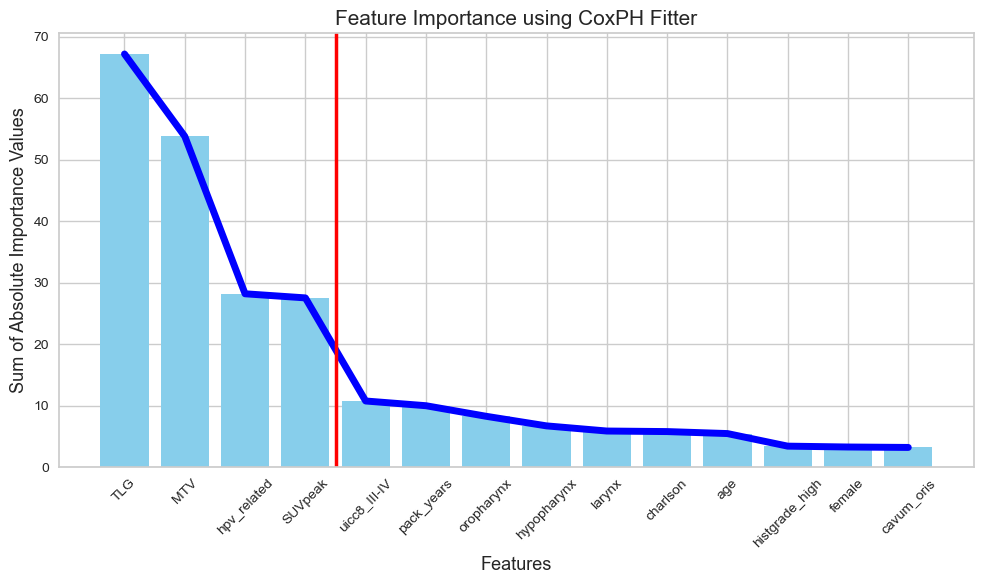

In [62]:
# Plot the bar graph
plt.figure(figsize=(10, 6)) 
plt.bar(final_sum_sorted['Feature'], 
        final_sum_sorted['Final_Sum_Abs_Coefficient'], 
        color='skyblue')
plt.plot(final_sum_sorted['Feature'], 
         final_sum_sorted['Final_Sum_Abs_Coefficient'], 
         color='blue',
        linewidth=5)
plt.xlabel('Features', fontsize=13) 
plt.ylabel('Sum of Absolute Importance Values', fontsize=13) 
plt.title('Feature Importance using CoxPH Fitter', fontsize=15)
plt.xticks(rotation=45) 
plt.axvline(x=3.5, color='red', linestyle='-', linewidth=2.5) 
plt.tight_layout()  
plt.show()

In [63]:
selected_features = final_sum_sorted[0:4]['Feature']
selected_features

2            TLG
0            MTV
8    hpv_related
1        SUVpeak
Name: Feature, dtype: object

In [64]:
# Selecting features in the DataFrame
X_cfi = X[selected_features]
X_new = X_cfi.copy()

X_MAASTRO_cfi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_cfi.copy()

In [65]:
X_new.shape

(139, 4)

# Yeo-Johnson Transformation

In [78]:
# Transform X_new 
# Set the categorical_columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_transformed = pt.fit_transform(X_new_numeric)

# Create DataFrame with transformed numerical data
X_new_numeric_transformed = pd.DataFrame(X_new_numeric_transformed, 
                                         columns=X_new_numeric.columns, 
                                         index=X_new.index)

# Concatenate transformed numerical data with categorical data
X_new_std = pd.concat([X_new_numeric_transformed, X_new_categoric], axis=1)

# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the transformation for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]
MAASTRO_new  = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [79]:
X_new

,TLG,MTV,hpv_related,SUVpeak
0,86.228420,7.934,0.0,14.473272
1,7.040100,1.656,0.0,5.044678
2,83.569669,14.502,0.0,7.839043
3,5.567091,2.440,0.0,2.880631
4,16.150550,3.668,0.0,5.402006
...,...,...,...,...
134,26.280140,3.650,1.0,9.290139
135,101.754834,18.967,1.0,7.172883
136,66.273201,6.370,1.0,13.873187
137,71.832443,12.443,1.0,7.507419


In [80]:
X_new_std

,TLG,MTV,hpv_related,SUVpeak
0,0.343545,0.080033,0.0,0.750782
1,-1.657833,-1.722060,0.0,-1.213660
2,0.318631,0.735716,0.0,-0.474112
3,-1.835650,-1.291020,0.0,-1.992620
4,-1.003396,-0.816679,0.0,-1.106304
...,...,...,...,...
134,-0.611074,-0.822461,1.0,-0.158214
135,0.474941,1.008070,1.0,-0.632361
136,0.133612,-0.170908,1.0,0.658564
137,0.197985,0.574668,1.0,-0.551725


In [81]:
MAASTRO_new

,TLG,MTV,hpv_related,SUVpeak
0,263.611623,22.841,1,15.438583
1,36.980700,5.660,0,8.829353
2,74.636342,7.791,0,13.476123
3,46.791979,7.908,0,8.632732
4,107.637514,15.237,1,9.783954
...,...,...,...,...
94,144.490782,6.110,0,31.338410
95,69.214868,7.182,0,13.041604
96,102.594274,16.483,1,8.944517
97,103.229492,9.981,1,14.184236


In [82]:
MAASTRO_new_std

,TLG,MTV,hpv_related,SUVpeak
0,1.218887,1.188930,1,0.893634
1,-0.335276,-0.307894,0,-0.254678
2,0.228548,0.059450,0,0.595996
3,-0.145668,0.076321,0,-0.296877
4,0.519421,0.786849,1,-0.058378
...,...,...,...,...
94,0.751363,-0.219083,0,2.645651
95,0.168333,-0.033134,0,0.526028
96,0.481447,0.867254,1,-0.230255
97,0.486335,0.336049,1,0.706707


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [83]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]

            # Find intersection of excluded columns with X columns
            excluded_columns = set(excluded_columns).intersection(X.columns)

            # Extract included columns
            included_columns = [col for col in X.columns if col not in excluded_columns]

            # Extract numerical data for included columns
            X_train_included = X_train[included_columns]
            X_test_included = X_test[included_columns]

            # Apply Yeo-Johnson transformation
            pt = PowerTransformer(method='yeo-johnson')
            X_train_included_transformed = pt.fit_transform(X_train_included)
            X_test_included_transformed = pt.transform(X_test_included)

            # Create DataFrame with transformed numerical data
            X_train_included_transformed_df = pd.DataFrame(X_train_included_transformed, columns=included_columns, index=X_train_included.index)
            X_test_included_transformed_df = pd.DataFrame(X_test_included_transformed, columns=included_columns, index=X_test_included.index)

            # Concatenate transformed numerical data with excluded columns
            X_train_std = pd.concat([X_train_included_transformed_df, X_train[list(excluded_columns)]], axis=1)
            X_test_std = pd.concat([X_test_included_transformed_df, X_test[list(excluded_columns)]], axis=1)

            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:41:17,891] A new study created in memory with name: no-name-6838b471-bac3-4c59-983b-e7b63ef5eb60


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6294820717131474
Fold 2 C-index: 0.6705426356589147
Fold 3 C-index: 0.7319148936170212


[I 2024-04-13 17:41:18,607] A new study created in memory with name: no-name-87fcfeab-ebbf-4c02-befb-ed6924935a2c


Fold 4 C-index: 0.6768060836501901
Fold 5 C-index: 0.5493562231759657
[I 2024-04-13 17:41:18,599] Trial 0 finished with value: 0.6516203815630479 and parameters: {}. Best is trial 0 with value: 0.6516203815630479.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6516203815630479], datetime_start=datetime.datetime(2024, 4, 13, 17, 41, 18, 12236), datetime_complete=datetime.datetime(2024, 4, 13, 17, 41, 18, 598837), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6516203815630479


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2203225743515189
Fold 2 IBS: 0.20798441952197022
Fold 3 IBS: 0.21404289137863067
Fold 4 IBS: 0.24148712255314256
Fold 5 IBS: 0.23101598911806476
[I 2024-04-13 17:41:19,595] Trial 0 finished with value: 0.2229705993846654 and parameters: {}. Best is trial 0 with value: 0.2229705993846654.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2229705993846654], datetime_start=datetime.datetime(2024, 4, 13, 17, 41, 18, 644608), datetime_complete=datetime.datetime(2024, 4, 13, 17, 41, 19, 595118), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2229705993846654


In [84]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [85]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.652
train_ibs:  0.223


#### Test

In [86]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [87]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.603
IBS score: 0.263


In [88]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [89]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [90]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])


            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]

            # Find intersection of excluded columns with X columns
            excluded_columns = set(excluded_columns).intersection(X.columns)

            # Extract included columns
            included_columns = [col for col in X.columns if col not in excluded_columns]

            # Extract numerical data for included columns
            X_train_included = X_train[included_columns]
            X_test_included = X_test[included_columns]

            # Apply Yeo-Johnson transformation
            pt = PowerTransformer(method='yeo-johnson')
            X_train_included_transformed = pt.fit_transform(X_train_included)
            X_test_included_transformed = pt.transform(X_test_included)

            # Create DataFrame with transformed numerical data
            X_train_included_transformed_df = pd.DataFrame(X_train_included_transformed, columns=included_columns, index=X_train_included.index)
            X_test_included_transformed_df = pd.DataFrame(X_test_included_transformed, columns=included_columns, index=X_test_included.index)

            # Concatenate transformed numerical data with excluded columns
            X_train_std = pd.concat([X_train_included_transformed_df, X_train[list(excluded_columns)]], axis=1)
            X_test_std = pd.concat([X_test_included_transformed_df, X_test[list(excluded_columns)]], axis=1)

            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:41:21,945] A new study created in memory with name: no-name-c0bf3114-1129-480f-b640-f732ff7a9b30


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5278884462151394
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192


[I 2024-04-13 17:41:22,423] A new study created in memory with name: no-name-2414146e-fee2-4bbf-9951-224134b46ce0


Fold 4 C-index: 0.46387832699619774
Fold 5 C-index: 0.4592274678111588
[I 2024-04-13 17:41:22,417] Trial 0 finished with value: 0.5437729864199042 and parameters: {}. Best is trial 0 with value: 0.5437729864199042.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5437729864199042], datetime_start=datetime.datetime(2024, 4, 13, 17, 41, 21, 982981), datetime_complete=datetime.datetime(2024, 4, 13, 17, 41, 22, 417643), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5437729864199042


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724709759262753
Fold 2 IBS: 0.2320398829421048
Fold 3 IBS: 0.22898186520676508
Fold 4 IBS: 0.2419747810802329
Fold 5 IBS: 0.22939559423177697
[I 2024-04-13 17:41:23,023] Trial 0 finished with value: 0.23592784421070143 and parameters: {}. Best is trial 0 with value: 0.23592784421070143.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784421070143], datetime_start=datetime.datetime(2024, 4, 13, 17, 41, 22, 454400), datetime_complete=datetime.datetime(2024, 4, 13, 17, 41, 23, 23465), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784421070143


In [91]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [92]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.544
train_ibs:  0.236


#### Test

In [93]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [94]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.616


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [95]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [96]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]

            # Find intersection of excluded columns with X columns
            excluded_columns = set(excluded_columns).intersection(X.columns)

            # Extract included columns
            included_columns = [col for col in X.columns if col not in excluded_columns]

            # Extract numerical data for included columns
            X_train_included = X_train[included_columns]
            X_test_included = X_test[included_columns]

            # Apply Yeo-Johnson transformation
            pt = PowerTransformer(method='yeo-johnson')
            X_train_included_transformed = pt.fit_transform(X_train_included)
            X_test_included_transformed = pt.transform(X_test_included)

            # Create DataFrame with transformed numerical data
            X_train_included_transformed_df = pd.DataFrame(X_train_included_transformed, columns=included_columns, index=X_train_included.index)
            X_test_included_transformed_df = pd.DataFrame(X_test_included_transformed, columns=included_columns, index=X_test_included.index)

            # Concatenate transformed numerical data with excluded columns
            X_train_std = pd.concat([X_train_included_transformed_df, X_train[list(excluded_columns)]], axis=1)
            X_test_std = pd.concat([X_test_included_transformed_df, X_test[list(excluded_columns)]], axis=1)

            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:41:23,518] A new study created in memory with name: no-name-cddc858d-71e8-4c07-94ec-14126b4c95fb


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6294820717131474
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.6615969581749049


[I 2024-04-13 17:41:24,804] A new study created in memory with name: no-name-f380fb27-787b-4c60-a01e-d65b838790e9


Fold 5 C-index: 0.5536480686695279
[I 2024-04-13 17:41:24,795] Trial 0 finished with value: 0.65106318319494 and parameters: {}. Best is trial 0 with value: 0.65106318319494.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.65106318319494], datetime_start=datetime.datetime(2024, 4, 13, 17, 41, 23, 567144), datetime_complete=datetime.datetime(2024, 4, 13, 17, 41, 24, 794574), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.65106318319494


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.22080821264101053
Fold 2 IBS: 0.2092913108187401
Fold 3 IBS: 0.21078005542926176
Fold 4 IBS: 0.24308913545880229
Fold 5 IBS: 0.2298139223857434
[I 2024-04-13 17:41:26,065] Trial 0 finished with value: 0.22275652734671164 and parameters: {}. Best is trial 0 with value: 0.22275652734671164.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.22275652734671164], datetime_start=datetime.datetime(2024, 4, 13, 17, 41, 24, 926380), datetime_complete=datetime.datetime(2024, 4, 13, 17, 41, 26, 64705), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.22275652734671164


In [97]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [98]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.651
train_ibs:  0.223


#### Test

In [99]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [100]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.611


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.245


In [101]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [102]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]

            # Find intersection of excluded columns with X columns
            excluded_columns = set(excluded_columns).intersection(X.columns)

            # Extract included columns
            included_columns = [col for col in X.columns if col not in excluded_columns]

            # Extract numerical data for included columns
            X_train_included = X_train[included_columns]
            X_test_included = X_test[included_columns]

            # Apply Yeo-Johnson transformation
            pt = PowerTransformer(method='yeo-johnson')
            X_train_included_transformed = pt.fit_transform(X_train_included)
            X_test_included_transformed = pt.transform(X_test_included)

            # Create DataFrame with transformed numerical data
            X_train_included_transformed_df = pd.DataFrame(X_train_included_transformed, columns=included_columns, index=X_train_included.index)
            X_test_included_transformed_df = pd.DataFrame(X_test_included_transformed, columns=included_columns, index=X_test_included.index)

            # Concatenate transformed numerical data with excluded columns
            X_train_std = pd.concat([X_train_included_transformed_df, X_train[list(excluded_columns)]], axis=1)
            X_test_std = pd.concat([X_test_included_transformed_df, X_test[list(excluded_columns)]], axis=1)

            model.fit(X_train_std, y_train)


            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 17:41:26,813] A new study created in memory with name: no-name-fa4f8207-b176-49d5-9401-3b7505b4cb8f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6294820717131474
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.6577946768060836
Fold 5 C-index: 0.5536480686695279
[I 2024-04-13 17:41:28,309] Trial 0 finished with value: 0.6503027269211759 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6503027269211759.
Fold 1 C-index: 0.6294820717131474
Fold 2 C-index: 0.6705426356589147
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.6539923954372624
Fold 5 C-index: 0.5536480686695279
[I 2024-04-13 17:41:29,709] Trial 1 finished with value: 0.648767076848962 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.6503027269211759.
Fold 1 C-index: 0.6294820717131474
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.6539923954372624
Fold 5 C-index: 0.5536480686695279
[I 2024-04-13 17:41:30,603] Trial 2 finished with value: 0.6209986453793924 and parameters: {'l1_ratio': 0.22692876841884668}. 

Fold 1 C-index: 0.6294820717131474
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.6577946768060836
Fold 5 C-index: 0.5536480686695279
[I 2024-04-13 17:41:56,678] Trial 24 finished with value: 0.6503027269211759 and parameters: {'l1_ratio': 0.7805647035680947}. Best is trial 6 with value: 0.65106318319494.
Fold 1 C-index: 0.6294820717131474
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.6615969581749049
Fold 5 C-index: 0.5536480686695279
[I 2024-04-13 17:41:57,571] Trial 25 finished with value: 0.65106318319494 and parameters: {'l1_ratio': 0.9368557715647121}. Best is trial 6 with value: 0.65106318319494.
Fold 1 C-index: 0.5378486055776892
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.4600760456273764
Fold 5 C-index: 0.45493562231759654
[I 2024-04-13 17:41:58,227] Trial 26 finished with value: 0.5441461929199374 and parameters: {'l1_ratio': 0.015423757551295547}. B

Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.6615969581749049
Fold 5 C-index: 0.5536480686695279
[I 2024-04-13 17:42:22,583] Trial 48 finished with value: 0.65106318319494 and parameters: {'l1_ratio': 0.8619031648167028}. Best is trial 6 with value: 0.65106318319494.
Fold 1 C-index: 0.6294820717131474
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.6615969581749049
Fold 5 C-index: 0.5536480686695279
[I 2024-04-13 17:42:23,635] Trial 49 finished with value: 0.65106318319494 and parameters: {'l1_ratio': 0.920787420171088}. Best is trial 6 with value: 0.65106318319494.
Fold 1 C-index: 0.6294820717131474
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.6577946768060836
Fold 5 C-index: 0.5536480686695279
[I 2024-04-13 17:42:24,811] Trial 50 finished with value: 0.6503027269211759 and parameters: {'l1_ratio': 0.8176586649944165}. Best is trial 6 with value: 0.651063183194

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.22086186831089266
Fold 2 IBS: 0.20912833360766983
Fold 3 IBS: 0.2108990439883777
Fold 4 IBS: 0.24340438084044003
Fold 5 IBS: 0.22972427970540044
[I 2024-04-13 17:43:28,244] Trial 0 finished with value: 0.22280358129055614 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.22280358129055614.
Fold 1 IBS: 0.2209546936174143
Fold 2 IBS: 0.2088877661953104
Fold 3 IBS: 0.21084169855654683
Fold 4 IBS: 0.24380113890514352
Fold 5 IBS: 0.22986211696200373
[I 2024-04-13 17:43:29,549] Trial 1 finished with value: 0.22286948284728375 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.22280358129055614.
Fold 1 IBS: 0.2209726054000205
Fold 2 IBS: 0.22910469892979343
Fold 3 IBS: 0.2234674652030817
Fold 4 IBS: 0.24386369405001732
Fold 5 IBS: 0.22986071327852922
[I 2024-04-13 17:43:30,821] Trial 2 finished with value: 0.22945383537228844 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.22280358129055

Fold 1 IBS: 0.22082681125586928
Fold 2 IBS: 0.20923511039347856
Fold 3 IBS: 0.2108243638173798
Fold 4 IBS: 0.24319180324244577
Fold 5 IBS: 0.22982655717464967
[I 2024-04-13 17:44:00,456] Trial 25 finished with value: 0.22278092917676462 and parameters: {'l1_ratio': 0.8906153790545669}. Best is trial 12 with value: 0.222748268112339.
Fold 1 IBS: 0.22087573305449887
Fold 2 IBS: 0.20908867545992532
Fold 3 IBS: 0.21087764872654144
Fold 4 IBS: 0.2434729241598278
Fold 5 IBS: 0.22972379691564612
[I 2024-04-13 17:44:01,792] Trial 26 finished with value: 0.22280775566328792 and parameters: {'l1_ratio': 0.6273790955054189}. Best is trial 12 with value: 0.222748268112339.
Fold 1 IBS: 0.24678956709750774
Fold 2 IBS: 0.23177969488933825
Fold 3 IBS: 0.22851349496915102
Fold 4 IBS: 0.24333193835808897
Fold 5 IBS: 0.22953957351762216
[I 2024-04-13 17:44:02,456] Trial 27 finished with value: 0.23599085376634163 and parameters: {'l1_ratio': 0.016560941611969082}. Best is trial 12 with value: 0.222748268

Fold 1 IBS: 0.2208140081359464
Fold 2 IBS: 0.2092643287455974
Fold 3 IBS: 0.21079669908874693
Fold 4 IBS: 0.24316287291413063
Fold 5 IBS: 0.2297441707039052
[I 2024-04-13 17:44:50,820] Trial 50 finished with value: 0.22275641591766532 and parameters: {'l1_ratio': 0.9460928177583293}. Best is trial 12 with value: 0.222748268112339.
Fold 1 IBS: 0.22081285938991213
Fold 2 IBS: 0.2092691631410519
Fold 3 IBS: 0.21085344113189244
Fold 4 IBS: 0.24315792192083968
Fold 5 IBS: 0.22979219519324928
[I 2024-04-13 17:44:52,071] Trial 51 finished with value: 0.2227771161553891 and parameters: {'l1_ratio': 0.9562724397566018}. Best is trial 12 with value: 0.222748268112339.
Fold 1 IBS: 0.2208311007998661
Fold 2 IBS: 0.20921948792699469
Fold 3 IBS: 0.21087918171687545
Fold 4 IBS: 0.24325000628074553
Fold 5 IBS: 0.22978396347091204
[I 2024-04-13 17:44:53,467] Trial 52 finished with value: 0.22279274803907878 and parameters: {'l1_ratio': 0.8552962105134653}. Best is trial 12 with value: 0.222748268112339

Fold 1 IBS: 0.2208257724025142
Fold 2 IBS: 0.20923992705618394
Fold 3 IBS: 0.21086842840956577
Fold 4 IBS: 0.2431868523558712
Fold 5 IBS: 0.22980469616804622
[I 2024-04-13 17:45:19,727] Trial 75 finished with value: 0.2227851352784363 and parameters: {'l1_ratio': 0.8996523424618287}. Best is trial 56 with value: 0.22271413752818026.
Fold 1 IBS: 0.2208101742710287
Fold 2 IBS: 0.20928051984901264
Fold 3 IBS: 0.21083058262880133
Fold 4 IBS: 0.2431463066921769
Fold 5 IBS: 0.2297504347017183
[I 2024-04-13 17:45:20,825] Trial 76 finished with value: 0.22276360362854755 and parameters: {'l1_ratio': 0.9810187390799374}. Best is trial 56 with value: 0.22271413752818026.
Fold 1 IBS: 0.2208083594137328
Fold 2 IBS: 0.20929062794538905
Fold 3 IBS: 0.2107732785035129
Fold 4 IBS: 0.2430898372784036
Fold 5 IBS: 0.22981041556698556
[I 2024-04-13 17:45:21,876] Trial 77 finished with value: 0.22275450374160483 and parameters: {'l1_ratio': 0.9985522143197298}. Best is trial 56 with value: 0.22271413752818

In [103]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [104]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.651
train_ibs:  0.223


#### Test

In [105]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [106]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.980766121964777)

test_cindex : 0.61


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.993291324362003)

test_ibs:  0.245


In [107]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [108]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 17:45:52,868] A new study created in memory with name: no-name-b6e64a52-3dc1-4b2d-bdc4-1cf17e0bfa8d


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6314741035856574
Fold 2 C-index: 0.5872093023255814
Fold 3 C-index: 0.7723404255319148
Fold 4 C-index: 0.6463878326996197
Fold 5 C-index: 0.5407725321888412
[I 2024-04-13 17:46:02,799] Trial 0 finished with value: 0.635636839266323 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.635636839266323.
Fold 1 C-index: 0.5816733067729084
Fold 2 C-index: 0.6046511627906976
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.5855513307984791
Fold 5 C-index: 0.6094420600858369
[I 2024-04-13 17:46:09,481] Trial 1 finished with value: 0.6234976146427759 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'm

Fold 5 C-index: 0.6094420600858369
[I 2024-04-13 17:47:35,257] Trial 15 finished with value: 0.6309048901588248 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 2, 'min_samples_leaf': 7, 'max_depth': 14, 'n_estimators': 79, 'oob_score': False, 'max_samples': 0.9887043893136873, 'max_features': None, 'min_weight_fraction_leaf': 0.11311294291919405, 'warm_start': False}. Best is trial 2 with value: 0.6390985051805438.
Fold 1 C-index: 0.6294820717131474
Fold 2 C-index: 0.6647286821705426
Fold 3 C-index: 0.6829787234042554
Fold 4 C-index: 0.55893536121673
Fold 5 C-index: 0.5236051502145923
[I 2024-04-13 17:47:50,314] Trial 16 finished with value: 0.6119459977438535 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 14, 'min_samples_leaf': 14, 'max_depth': 14, 'n_estimators': 475, 'oob_score': False, 'max_samples': 0.6976003666324501, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.22594306843997863, 'warm_start': False}. Best is trial 2 with value: 0.63909850518054

Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:49:49,336] Trial 30 finished with value: 0.5 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 19, 'min_samples_leaf': 18, 'max_depth': 6, 'n_estimators': 392, 'oob_score': True, 'max_samples': 0.20745212948125213, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.22089640196610735, 'warm_start': True}. Best is trial 29 with value: 0.6691956485410945.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 17:49:54,620] Trial 31 finished with value: 0.5 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 17, 'min_samples_leaf': 18, 'max_depth': 3, 'n_estimators': 372, 'oob_score': True, 'max_samples': 0.4110607864254019, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.23305012521106167, 'warm_start': True}. Best is trial 29 with value: 0.6691956485410945.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-ind

...

Fold 5 IBS: 0.21347611107355272
[I 2024-04-13 17:58:47,784] Trial 31 finished with value: 0.22101626363146015 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 2, 'min_samples_leaf': 3, 'max_depth': 10, 'n_estimators': 219, 'oob_score': False, 'max_samples': 0.9010552304640113, 'max_features': None, 'min_weight_fraction_leaf': 0.31663356146605026}. Best is trial 21 with value: 0.22012096012805404.
Fold 1 IBS: 0.22425132675844717
Fold 2 IBS: 0.22909599757876872
Fold 3 IBS: 0.20886579669101024
Fold 4 IBS: 0.23396899575937236
Fold 5 IBS: 0.21454587401970843
[I 2024-04-13 17:58:56,502] Trial 32 finished with value: 0.22214559816146137 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 4, 'min_samples_leaf': 4, 'max_depth': 13, 'n_estimators': 135, 'oob_score': False, 'max_samples': 0.9502203520505428, 'max_features': None, 'min_weight_fraction_leaf': 0.36496701991242364}. Best is trial 21 with value: 0.22012096012805404.
Fold 1 IBS: 0.22649332435743216
Fold 2 IBS: 0.2296

Fold 1 IBS: 0.23392250802901046
Fold 2 IBS: 0.2276176334398665
Fold 3 IBS: 0.21765023355481117
Fold 4 IBS: 0.24681391801487979
Fold 5 IBS: 0.2230698662741196
[I 2024-04-13 18:01:25,372] Trial 47 finished with value: 0.22981483186253748 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 15, 'min_samples_leaf': 6, 'max_depth': 12, 'n_estimators': 167, 'oob_score': True, 'max_samples': 0.7472962433297521, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.28861390752210875}. Best is trial 21 with value: 0.22012096012805404.
Fold 1 IBS: 0.22513407788476433
Fold 2 IBS: 0.23485205937186882
Fold 3 IBS: 0.20736515729682434
Fold 4 IBS: 0.23327275622968227
Fold 5 IBS: 0.21990689242587155
[I 2024-04-13 18:01:33,263] Trial 48 finished with value: 0.22410618864180226 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 13, 'min_samples_leaf': 17, 'max_depth': 8, 'n_estimators': 107, 'oob_score': False, 'max_samples': 0.8880960419591427, 'max_features': None, 'min_weight_fraction_

Fold 1 IBS: 0.2214256608553594
Fold 2 IBS: 0.22989608951443957
Fold 3 IBS: 0.20570071233636794
Fold 4 IBS: 0.22983524368001798
Fold 5 IBS: 0.21486513709750413
[I 2024-04-13 18:03:33,454] Trial 63 finished with value: 0.2203445686967378 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 4, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 175, 'oob_score': False, 'max_samples': 0.9816497825103989, 'max_features': None, 'min_weight_fraction_leaf': 0.3099477184851532}. Best is trial 62 with value: 0.220049109766076.
Fold 1 IBS: 0.23579640187705891
Fold 2 IBS: 0.22627555353278606
Fold 3 IBS: 0.21106808083245196
Fold 4 IBS: 0.22559498307188094
Fold 5 IBS: 0.22307552686779777
[I 2024-04-13 18:03:39,764] Trial 64 finished with value: 0.22436210923639513 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 4, 'min_samples_leaf': 7, 'max_depth': 11, 'n_estimators': 163, 'oob_score': False, 'max_samples': 0.9984339979609403, 'max_features': None, 'min_weight_fraction_leaf':

Fold 1 IBS: 0.24388556508745277
Fold 2 IBS: 0.23639015673689004
Fold 3 IBS: 0.23629265319128825
Fold 4 IBS: 0.254705961695029
Fold 5 IBS: 0.23425319861564578
[I 2024-04-13 18:05:42,875] Trial 79 finished with value: 0.24110550706526118 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 2, 'min_samples_leaf': 5, 'max_depth': 9, 'n_estimators': 141, 'oob_score': False, 'max_samples': 0.7799301662590719, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.3619700300075978}. Best is trial 62 with value: 0.220049109766076.
Fold 1 IBS: 0.22155656610884114
Fold 2 IBS: 0.227973557169275
Fold 3 IBS: 0.20622547432962357
Fold 4 IBS: 0.2346185623043711
Fold 5 IBS: 0.2134548558722584
[I 2024-04-13 18:05:49,282] Trial 80 finished with value: 0.22076580315687383 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 8, 'min_samples_leaf': 2, 'max_depth': 7, 'n_estimators': 169, 'oob_score': False, 'max_samples': 0.9068955756105657, 'max_features': None, 'min_weight_fraction_leaf': 0.3

Fold 1 IBS: 0.2244475335831985
Fold 2 IBS: 0.22802950720359258
Fold 3 IBS: 0.2100128221845491
Fold 4 IBS: 0.232844866940705
Fold 5 IBS: 0.21466892133544035
[I 2024-04-13 18:08:56,112] Trial 95 finished with value: 0.22200073024949712 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 5, 'min_samples_leaf': 1, 'max_depth': 1, 'n_estimators': 327, 'oob_score': True, 'max_samples': 0.9308888433812464, 'max_features': None, 'min_weight_fraction_leaf': 0.36014553984105474}. Best is trial 87 with value: 0.21971521590548182.
Fold 1 IBS: 0.23026886247401096
Fold 2 IBS: 0.22493019438221237
Fold 3 IBS: 0.21469978181881108
Fold 4 IBS: 0.2418050862047304
Fold 5 IBS: 0.22091500142398648
[I 2024-04-13 18:09:15,627] Trial 96 finished with value: 0.2265237852607503 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 7, 'min_samples_leaf': 2, 'max_depth': 4, 'n_estimators': 390, 'oob_score': True, 'max_samples': 0.8993027512409215, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.

In [109]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [110]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.762
train_ibs:  0.22


#### Test

In [111]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [112]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=18, max_features='log2', max_leaf_nodes=6,
                     max_samples=0.9275321993564254, min_samples_leaf=2,
                     min_samples_split=16,
                     min_weight_fraction_leaf=0.022752009973524792,
                     n_estimators=140, oob_score=True, random_state=123,
                     warm_start=True)

test_cindex:  0.582


RandomSurvivalForest(max_depth=6, max_features=None, max_leaf_nodes=5,
                     max_samples=0.9992545995423986, min_samples_leaf=1,
                     min_samples_split=19,
                     min_weight_fraction_leaf=0.33386469508320393,
                     n_estimators=286, oob_score=True, random_state=123)

test_ibs:  0.223


In [113]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [114]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 18:10:18,762] A new study created in memory with name: no-name-079ccf87-1fe7-4680-9fde-e98f5f9e15b8


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6235059760956175
Fold 2 C-index: 0.6821705426356589
Fold 3 C-index: 0.8042553191489362
Fold 4 C-index: 0.7034220532319392
Fold 5 C-index: 0.6695278969957081
[I 2024-04-13 18:10:21,408] Trial 0 finished with value: 0.696576357621572 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.696576357621572.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:10:28,585] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}.

Fold 3 C-index: 0.825531914893617
Fold 4 C-index: 0.6996197718631179
Fold 5 C-index: 0.5665236051502146
[I 2024-04-13 18:11:48,463] Trial 15 finished with value: 0.6717832809948122 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.6993148466480502.
Fold 1 C-index: 0.599601593625498
Fold 2 C-index: 0.6124031007751938
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.6749049429657795
Fold 5 C-index: 0.5622317596566524
[I 2024-04-13 18:11:53,812] Trial 16 finished with value: 0.6464240240854758 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_l

Fold 1 C-index: 0.6314741035856574
Fold 2 C-index: 0.6705426356589147
Fold 3 C-index: 0.7957446808510639
Fold 4 C-index: 0.7053231939163498
Fold 5 C-index: 0.6180257510729614
[I 2024-04-13 18:12:50,127] Trial 30 finished with value: 0.6842220730169893 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 11, 'min_samples_leaf': 9, 'max_depth': 16, 'n_estimators': 404, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.8221885453005676, 'min_weight_fraction_leaf': 0.03868084640768137}. Best is trial 23 with value: 0.7058621668374488.
Fold 1 C-index: 0.6374501992031872
Fold 2 C-index: 0.6937984496124031
Fold 3 C-index: 0.7787234042553192
Fold 4 C-index: 0.7034220532319392
Fold 5 C-index: 0.6180257510729614
[I 2024-04-13 18:12:53,356] Trial 31 finished with value: 0.686283971475162 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 8, 'min_samples_leaf': 1, 'max_depth': 8, 'n_estimators': 350, 'oob_score': False, 'warm_start': True, 'max_featur

...

Fold 1 IBS: 0.23948200408204467
Fold 2 IBS: 0.22791399785671246
Fold 3 IBS: 0.2238179909867456
Fold 4 IBS: 0.23475678762765448
Fold 5 IBS: 0.22139842256575362
[I 2024-04-13 18:22:18,956] Trial 30 finished with value: 0.22947384062378218 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 5, 'max_depth': 2, 'n_estimators': 69, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.2360776325514759, 'min_weight_fraction_leaf': 0.10254099431572808}. Best is trial 19 with value: 0.2183184356647331.
Fold 1 IBS: 0.22452558193725225
Fold 2 IBS: 0.2260144320296366
Fold 3 IBS: 0.20616243163430595
Fold 4 IBS: 0.2227895055336173
Fold 5 IBS: 0.21340441422364023
[I 2024-04-13 18:22:24,442] Trial 31 finished with value: 0.2185792730716905 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 6, 'min_samples_leaf': 4, 'max_depth': 6, 'n_estimators': 165, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.582

Fold 1 IBS: 0.2213263201768676
Fold 2 IBS: 0.22772113139649114
Fold 3 IBS: 0.20786124072699225
Fold 4 IBS: 0.21511418854827472
Fold 5 IBS: 0.21181251685416194
[I 2024-04-13 18:23:47,210] Trial 45 finished with value: 0.21676707954055754 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 2, 'min_samples_leaf': 12, 'max_depth': 11, 'n_estimators': 38, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.8581223115835608, 'min_weight_fraction_leaf': 0.021520071756413822}. Best is trial 34 with value: 0.21587329054107776.
Fold 1 IBS: 0.23420441039874856
Fold 2 IBS: 0.22474008860171052
Fold 3 IBS: 0.21813999336400106
Fold 4 IBS: 0.22998458736775051
Fold 5 IBS: 0.21790817195408396
[I 2024-04-13 18:23:49,188] Trial 46 finished with value: 0.22499545033725893 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 2, 'min_samples_leaf': 12, 'max_depth': 13, 'n_estimators': 30, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.8

Fold 1 IBS: 0.22263069738598557
Fold 2 IBS: 0.2281257775385079
Fold 3 IBS: 0.20678924640735938
Fold 4 IBS: 0.21506070506902322
Fold 5 IBS: 0.2120975102696773
[I 2024-04-13 18:24:48,711] Trial 60 finished with value: 0.21694078733411065 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 2, 'min_samples_leaf': 17, 'max_depth': 12, 'n_estimators': 18, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.9394221056391128, 'min_weight_fraction_leaf': 0.10902891565259493}. Best is trial 34 with value: 0.21587329054107776.
Fold 1 IBS: 0.21957536117751825
Fold 2 IBS: 0.2285340160175939
Fold 3 IBS: 0.20087958898080366
Fold 4 IBS: 0.22263994685057092
Fold 5 IBS: 0.21279238195999056
[I 2024-04-13 18:24:54,339] Trial 61 finished with value: 0.21688425899729546 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 3, 'min_samples_leaf': 1, 'max_depth': 9, 'n_estimators': 115, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.61929

Fold 1 IBS: 0.2223645443613776
Fold 2 IBS: 0.23582851515107506
Fold 3 IBS: 0.1965555957371509
Fold 4 IBS: 0.22223930055128877
Fold 5 IBS: 0.21513385001676952
[I 2024-04-13 18:27:02,541] Trial 75 finished with value: 0.21842436116353237 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 4, 'min_samples_leaf': 3, 'max_depth': 9, 'n_estimators': 292, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.7720678260840708, 'min_weight_fraction_leaf': 0.03875275975124326}. Best is trial 34 with value: 0.21587329054107776.
Fold 1 IBS: 0.2209243715735738
Fold 2 IBS: 0.23120873570052833
Fold 3 IBS: 0.19755094532609965
Fold 4 IBS: 0.2220929833004431
Fold 5 IBS: 0.21340564399190048
[I 2024-04-13 18:27:13,017] Trial 76 finished with value: 0.21703653597850908 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 3, 'min_samples_leaf': 5, 'max_depth': 8, 'n_estimators': 292, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.644564

Fold 1 IBS: 0.22149607672632293
Fold 2 IBS: 0.23241728228665193
Fold 3 IBS: 0.20222419086377097
Fold 4 IBS: 0.22117267218623066
Fold 5 IBS: 0.2133486533400118
[I 2024-04-13 18:29:02,038] Trial 90 finished with value: 0.21813177508059764 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 3, 'min_samples_leaf': 2, 'max_depth': 8, 'n_estimators': 105, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.658007392083232, 'min_weight_fraction_leaf': 0.09701670078605616}. Best is trial 34 with value: 0.21587329054107776.
Fold 1 IBS: 0.2204760909226093
Fold 2 IBS: 0.23264975977077437
Fold 3 IBS: 0.19997516859853084
Fold 4 IBS: 0.21930126615237808
Fold 5 IBS: 0.21289113116429248
[I 2024-04-13 18:29:09,599] Trial 91 finished with value: 0.21705868332171702 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 3, 'min_samples_leaf': 4, 'max_depth': 12, 'n_estimators': 191, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.8508

In [115]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [116]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.762
train_ibs:  0.216


#### Test

In [117]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [118]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=12, max_leaf_nodes=20,
                   max_samples=0.9706033105898769, min_samples_leaf=2,
                   min_samples_split=5,
                   min_weight_fraction_leaf=0.016376543038668805,
                   n_estimators=204, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.586


ExtraSurvivalTrees(max_depth=8, max_features=None, max_leaf_nodes=3,
                   max_samples=0.7275313072084888, min_samples_leaf=2,
                   min_samples_split=16,
                   min_weight_fraction_leaf=0.037167307803865623,
                   n_estimators=92, oob_score=True, random_state=123)

IBS: 0.221


In [119]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [120]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 18:30:17,227] A new study created in memory with name: no-name-3e1f16e4-e315-441f-b976-d391fc0d70ff


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:31:23,971] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:31:58,049] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:47:36,133] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.6366495686762917.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 18:49:30,948] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 5 C-index: 0.5
[I 2024-04-13 19:10:17,892] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.6366495686762917.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-13 19:12:47,738] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction_leaf': 0.35092096562

...

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:31:29,841] Trial 44 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5628832155203615, 'learning_rate': 0.05692286295358468, 'dropout_rate': 0.683156188511181, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 9.07255185322531, 'min_weight_fraction_leaf': 0.21518215373385774, 'max_features': None, 'min_impurity_decrease': 0.00078866474186123, 'validation_fraction': 0.8420815814864784, 'min_samples_split': 3, 'max_leaf_nodes': 11, 'min_samples_leaf': 17, 'max_depth': 10}. Best is trial 9 with value: 0.23563966177674858.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-13 21:31:40,331] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.9436582561003044, 'learning_rate': 0.07482848784358435, 'dropout_rate': 0.85957479691200

Fold 5 IBS: 0.22745532957226536
[I 2024-04-13 21:42:42,413] Trial 55 finished with value: 0.2336675039692598 and parameters: {'subsample': 0.5887322566034815, 'learning_rate': 0.03248154248395621, 'dropout_rate': 0.20419816136861105, 'n_estimators': 357, 'criterion': 'friedman_mse', 'ccp_alpha': 0.036799960796019306, 'min_weight_fraction_leaf': 0.30861253825639257, 'max_features': None, 'min_impurity_decrease': 0.0005802162560770055, 'validation_fraction': 0.4978860670989092, 'min_samples_split': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 9, 'max_depth': 13}. Best is trial 51 with value: 0.23271731423369696.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 21:43:48,551] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.48190513355031883, 'learning_rate': 0.030884976740502446, 'dropout_rate': 0.19804020971050568, 'n_estimators': 358

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 22:08:25,510] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.438028248164699, 'learning_rate': 0.03766085593505888, 'dropout_rate': 0.1895894544757071, 'n_estimators': 386, 'criterion': 'friedman_mse', 'ccp_alpha': 1.083648192803729, 'min_weight_fraction_leaf': 0.37503875397028397, 'max_features': None, 'min_impurity_decrease': 0.0014046872430471702, 'validation_fraction': 0.3956139648140855, 'min_samples_split': 2, 'max_leaf_nodes': 4, 'min_samples_leaf': 8, 'max_depth': 14}. Best is trial 51 with value: 0.23271731423369696.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 22:10:54,292] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsa

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.2419747714592711
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 22:23:38,565] Trial 78 finished with value: 0.2359278435123307 and parameters: {'subsample': 0.3686502019766869, 'learning_rate': 0.048491167717482735, 'dropout_rate': 0.19072333149111204, 'n_estimators': 255, 'criterion': 'friedman_mse', 'ccp_alpha': 0.2892263106266832, 'min_weight_fraction_leaf': 0.4454723403945225, 'max_features': None, 'min_impurity_decrease': 0.00038081001844946015, 'validation_fraction': 0.44682774336424097, 'min_samples_split': 2, 'max_leaf_nodes': 3, 'min_samples_leaf': 9, 'max_depth': 11}. Best is trial 51 with value: 0.23271731423369696.
Fold 1 IBS: 0.24601668397789453
Fold 2 IBS: 0.23099072510368704
Fold 3 IBS: 0.22764578611625594
Fold 4 IBS: 0.2420791170528608
Fold 5 IBS: 0.22915635698565798
[I 2024-04-13 22:24:35,888] Trial 79 finished with value: 0.23517773384727128 and parameters: {'subsample': 0.32859077945582116, '

Fold 3 IBS: 0.2276576995712535
Fold 4 IBS: 0.2417288730810276
Fold 5 IBS: 0.22823578661487973
[I 2024-04-13 23:35:13,956] Trial 89 finished with value: 0.23487189592245777 and parameters: {'subsample': 0.38730242337646104, 'learning_rate': 0.02421964397282719, 'dropout_rate': 0.17427867014331294, 'n_estimators': 282, 'criterion': 'friedman_mse', 'ccp_alpha': 0.019001072018239806, 'min_weight_fraction_leaf': 0.3951357034179224, 'max_features': None, 'min_impurity_decrease': 0.01806689386438656, 'validation_fraction': 0.5089000041945507, 'min_samples_split': 5, 'max_leaf_nodes': 6, 'min_samples_leaf': 13, 'max_depth': 9}. Best is trial 51 with value: 0.23271731423369696.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-13 23:35:56,042] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7804919801664709, 'learning_rate': 0.0410642753258228

In [121]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [122]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.666
train_ibs:  0.233


#### Test

In [123]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [124]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.04745907303323582,
                                 criterion='squared_error',
                                 dropout_rate=0.7656001076058049,
                                 learning_rate=0.06553064556446514,
                                 max_depth=14, max_features='auto',
                                 max_leaf_nodes=17,
                                 min_impurity_decrease=0.00013629488188736995,
                                 min_samples_leaf=17, min_samples_split=5,
                                 min_weight_fraction_leaf=0.11988934782365562,
                                 n_estimators=86, random_state=123,
                                 subsample=0.5990432053193259,
                                 validation_fraction=0.4644587353302381)

C-index score: 0.622


GradientBoostingSurvivalAnalysis(ccp_alpha=0.012687949334646564,
                                 dropout_rate=0.2080402615060769,
                                 learning_rate=0.04239876363366693,
                                 max_depth=12, max_leaf_nodes=4,
                                 min_impurity_decrease=0.00011584908890219409,
                                 min_samples_leaf=11,
                                 min_weight_fraction_leaf=0.34409642600595886,
                                 n_estimators=324, random_state=123,
                                 subsample=0.7104684936493832,
                                 validation_fraction=0.7396320573342624)

IBS: 0.226


In [125]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis


#### Train

In [126]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold( n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]

            # Find intersection of excluded columns with X columns
            excluded_columns = set(excluded_columns).intersection(X.columns)

            # Extract included columns
            included_columns = [col for col in X.columns if col not in excluded_columns]

            # Extract numerical data for included columns
            X_train_included = X_train[included_columns]
            X_test_included = X_test[included_columns]

            # Apply Yeo-Johnson transformation
            pt = PowerTransformer(method='yeo-johnson')
            X_train_included_transformed = pt.fit_transform(X_train_included)
            X_test_included_transformed = pt.transform(X_test_included)

            # Create DataFrame with transformed numerical data
            X_train_included_transformed_df = pd.DataFrame(X_train_included_transformed, columns=included_columns, index=X_train_included.index)
            X_test_included_transformed_df = pd.DataFrame(X_test_included_transformed, columns=included_columns, index=X_test_included.index)

            # Concatenate transformed numerical data with excluded columns
            X_train_std = pd.concat([X_train_included_transformed_df, X_train[list(excluded_columns)]], axis=1)
            X_test_std = pd.concat([X_test_included_transformed_df, X_test[list(excluded_columns)]], axis=1)

            model.fit(X_train_std, y_train)


            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:43:51,147] A new study created in memory with name: no-name-64d2c92d-8f1d-40bf-9761-1f204a5858a2


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6374501992031872
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.4600760456273764
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 23:43:53,285] Trial 0 finished with value: 0.5915343228038352 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5915343228038352.
Fold 1 C-index: 0.6374501992031872
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.46387832699619774
Fold 5 C-index: 0.592274678111588
[I 2024-04-13 23:44:35,685] Trial 1 finished with value: 0.5922947790775995 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.5922947790775995.
Fold 1 C-index: 0.6374501992031872
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.7787234042553192
Fold 4

Fold 1 C-index: 0.6414342629482072
Fold 2 C-index: 0.6782945736434108
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.4714828897338403
Fold 5 C-index: 0.5622317596566524
[I 2024-04-13 23:47:31,847] Trial 19 finished with value: 0.6272844418772732 and parameters: {'subsample': 0.3734884459569752, 'dropout_rate': 0.7254192287154788, 'n_estimators': 324, 'learning_rate': 0.08275918163679595}. Best is trial 12 with value: 0.637507349812162.
Fold 1 C-index: 0.6414342629482072
Fold 2 C-index: 0.6550387596899225
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.4828897338403042
Fold 5 C-index: 0.5708154506437768
[I 2024-04-13 23:47:39,064] Trial 20 finished with value: 0.6266313861052932 and parameters: {'subsample': 0.179916923106687, 'dropout_rate': 0.18714240181110126, 'n_estimators': 258, 'learning_rate': 0.03973446561107324}. Best is trial 12 with value: 0.637507349812162.
Fold 1 C-index: 0.6414342629482072
Fold 2 C-index: 0.6511627906976745
Fold 3 C-index: 0.7787234042553192
Fol

Fold 1 C-index: 0.6414342629482072
Fold 2 C-index: 0.6705426356589147
Fold 3 C-index: 0.774468085106383
Fold 4 C-index: 0.4828897338403042
Fold 5 C-index: 0.5622317596566524
[I 2024-04-13 23:50:43,737] Trial 38 finished with value: 0.6263132954420922 and parameters: {'subsample': 0.20254989040725885, 'dropout_rate': 0.15414981193981264, 'n_estimators': 280, 'learning_rate': 0.07288612365177065}. Best is trial 32 with value: 0.6380971803104986.
Fold 1 C-index: 0.6454183266932271
Fold 2 C-index: 0.6550387596899225
Fold 3 C-index: 0.7787234042553192
Fold 4 C-index: 0.4828897338403042
Fold 5 C-index: 0.5665236051502146
[I 2024-04-13 23:50:47,709] Trial 39 finished with value: 0.6257187659257976 and parameters: {'subsample': 0.13655780775635318, 'dropout_rate': 0.2640744432060189, 'n_estimators': 168, 'learning_rate': 0.0936203345332605}. Best is trial 32 with value: 0.6380971803104986.
Fold 1 C-index: 0.6374501992031872
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7829787234042553


...

Fold 2 IBS: 0.22900601544323335
Fold 3 IBS: 0.20322928411806995
Fold 4 IBS: 0.3070999140246978
Fold 5 IBS: 0.21307576641976478
[I 2024-04-14 00:33:13,446] Trial 19 finished with value: 0.2350238786364108 and parameters: {'subsample': 0.3892284838807411, 'dropout_rate': 0.7998935816367629, 'n_estimators': 131, 'learning_rate': 0.04079002339855972}. Best is trial 14 with value: 0.22860981386454862.
Fold 1 IBS: 0.24563691601100582
Fold 2 IBS: 0.23117688621315763
Fold 3 IBS: 0.22739413091103233
Fold 4 IBS: 0.2433176221882207
Fold 5 IBS: 0.22815012389723932
[I 2024-04-14 00:33:15,010] Trial 20 finished with value: 0.23513513584413115 and parameters: {'subsample': 0.6102628884762309, 'dropout_rate': 0.5558690358940764, 'n_estimators': 48, 'learning_rate': 0.0034226676404933015}. Best is trial 14 with value: 0.22860981386454862.
Fold 1 IBS: 0.22514587695905502
Fold 2 IBS: 0.22421684128440703
Fold 3 IBS: 0.20683412559918754
Fold 4 IBS: 0.2732564869554855
Fold 5 IBS: 0.21446385792330674
[I 2024

Fold 2 IBS: 0.27081654677863554
Fold 3 IBS: 0.223446666091345
Fold 4 IBS: 0.34885059574780136
Fold 5 IBS: 0.23480925329084104
[I 2024-04-14 00:34:38,014] Trial 38 finished with value: 0.2658703889140181 and parameters: {'subsample': 0.6190896853636969, 'dropout_rate': 0.13272164755980653, 'n_estimators': 199, 'learning_rate': 0.06754668991799195}. Best is trial 14 with value: 0.22860981386454862.
Fold 1 IBS: 0.22148048170684964
Fold 2 IBS: 0.23034877101559675
Fold 3 IBS: 0.20365508930555537
Fold 4 IBS: 0.3068122547743702
Fold 5 IBS: 0.21302091866700684
[I 2024-04-14 00:34:43,615] Trial 39 finished with value: 0.23506350309387578 and parameters: {'subsample': 0.43678668663924247, 'dropout_rate': 0.2873139612305017, 'n_estimators': 145, 'learning_rate': 0.03901462424612625}. Best is trial 14 with value: 0.22860981386454862.
Fold 1 IBS: 0.2618855237489678
Fold 2 IBS: 0.2955481059811013
Fold 3 IBS: 0.22942548757883655
Fold 4 IBS: 0.38991638159599296
Fold 5 IBS: 0.25727336797892975
[I 2024-

Fold 2 IBS: 0.22686559980327128
Fold 3 IBS: 0.2006835997467846
Fold 4 IBS: 0.31125162210380924
Fold 5 IBS: 0.21693778922570206
[I 2024-04-14 00:35:51,698] Trial 57 finished with value: 0.23511292628141783 and parameters: {'subsample': 0.1828916669072077, 'dropout_rate': 0.6600211623319744, 'n_estimators': 196, 'learning_rate': 0.03412100403393745}. Best is trial 54 with value: 0.22808312035539685.
Fold 1 IBS: 0.2413823236220203
Fold 2 IBS: 0.22877693924536865
Fold 3 IBS: 0.2224556449708585
Fold 4 IBS: 0.244521762151304
Fold 5 IBS: 0.2268024675193371
[I 2024-04-14 00:35:53,723] Trial 58 finished with value: 0.23278782750177776 and parameters: {'subsample': 0.2292584599603943, 'dropout_rate': 0.36573681723837637, 'n_estimators': 37, 'learning_rate': 0.0199212460928067}. Best is trial 54 with value: 0.22808312035539685.
Fold 1 IBS: 0.22507386219435607
Fold 2 IBS: 0.23346637259733424
Fold 3 IBS: 0.20442885509599987
Fold 4 IBS: 0.34349399506032363
Fold 5 IBS: 0.21465903759363308
[I 2024-04-

Fold 3 IBS: 0.21730741630860057
Fold 4 IBS: 0.24802319813902962
Fold 5 IBS: 0.22191184193574715
[I 2024-04-14 00:36:54,375] Trial 76 finished with value: 0.22971212956971465 and parameters: {'subsample': 0.23865347219058988, 'dropout_rate': 0.7331054973017869, 'n_estimators': 29, 'learning_rate': 0.052286236800626246}. Best is trial 61 with value: 0.2280598934293626.
Fold 1 IBS: 0.22368912044485037
Fold 2 IBS: 0.2233306533918518
Fold 3 IBS: 0.20555986694888015
Fold 4 IBS: 0.28588243023897525
Fold 5 IBS: 0.21535075809217571
[I 2024-04-14 00:36:57,278] Trial 77 finished with value: 0.23076256582334662 and parameters: {'subsample': 0.19629995972474126, 'dropout_rate': 0.5973330546075813, 'n_estimators': 90, 'learning_rate': 0.04567203342215214}. Best is trial 61 with value: 0.2280598934293626.
Fold 1 IBS: 0.23329790925093122
Fold 2 IBS: 0.22498350680728568
Fold 3 IBS: 0.21640625632040844
Fold 4 IBS: 0.25050909472163574
Fold 5 IBS: 0.22010548650837378
[I 2024-04-14 00:36:59,084] Trial 78 f

Fold 3 IBS: 0.20546970361839811
Fold 4 IBS: 0.2813116206851903
Fold 5 IBS: 0.21325580828650473
[I 2024-04-14 00:37:53,567] Trial 95 finished with value: 0.22982099532823336 and parameters: {'subsample': 0.37661120569872136, 'dropout_rate': 0.6486625177353432, 'n_estimators': 94, 'learning_rate': 0.04121491549919229}. Best is trial 61 with value: 0.2280598934293626.
Fold 1 IBS: 0.22921776270224292
Fold 2 IBS: 0.2232686747436265
Fold 3 IBS: 0.21141025978237077
Fold 4 IBS: 0.26306777674301846
Fold 5 IBS: 0.2176032060420248
[I 2024-04-14 00:37:56,650] Trial 96 finished with value: 0.22891353600265668 and parameters: {'subsample': 0.1803497871085052, 'dropout_rate': 0.622147926103211, 'n_estimators': 80, 'learning_rate': 0.03335008328753046}. Best is trial 61 with value: 0.2280598934293626.
Fold 1 IBS: 0.22208930909105115
Fold 2 IBS: 0.224936882280612
Fold 3 IBS: 0.2037310149985948
Fold 4 IBS: 0.29659914880272203
Fold 5 IBS: 0.21363968559934599
[I 2024-04-14 00:38:01,210] Trial 97 finished 

In [127]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [128]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.639
train_ibs:  0.228


#### Test

In [129]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [130]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.10140964346007082,
                                              learning_rate=0.08875748682122986,
                                              n_estimators=358,
                                              random_state=123,
                                              subsample=0.1259583152186484)

C-index score: 0.633


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.7087657863310202,
                                              learning_rate=0.042022475140005656,
                                              n_estimators=64, random_state=123,
                                              subsample=0.2627683317074049)

IBS: 0.219


In [131]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [132]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.762,1.5
ExtraSurvivalTrees,0.762,1.5
GradientBoosting,0.666,3.0
CoxPH,0.652,4.0
CoxLasso,0.651,5.5
CoxElastic,0.651,5.5
ComponentwiseGradientBoosting,0.639,7.0
CoxRidge,0.544,8.0


In [133]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.216,1.0
Randomsurvivalforest,0.220,2.0
CoxPH,0.223,4.0
CoxLasso,0.223,4.0
CoxElastic,0.223,4.0
ComponentwiseGradientBoosting,0.228,6.0
GradientBoosting,0.233,7.0
CoxRidge,0.236,8.0


In [134]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ComponentwiseGradientBoosting,0.633,1.0
GradientBoosting,0.622,2.0
CoxRidge,0.616,3.0
CoxLasso,0.611,4.0
CoxElastic,0.610,5.0
CoxPH,0.603,6.0
ExtraSurvivalTrees,0.586,7.0
Randomsurvivalforest,0.582,8.0


In [135]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ComponentwiseGradientBoosting,0.219,1.0
ExtraSurvivalTrees,0.221,2.0
Randomsurvivalforest,0.223,3.0
GradientBoosting,0.226,4.0
CoxRidge,0.229,5.0
CoxLasso,0.245,6.5
CoxElastic,0.245,6.5
CoxPH,0.263,8.0


In [136]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/dfs/yeojohnson/cfi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_dfs_yeojohnson_cfi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [137]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
